# Import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# data preprocesssing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Neural net moduel
from keras.models import Sequential # create a linear stack of neural network layers.
from keras.layers import Dense, Dropout # is a module that provides various layer types, including Dense and Dropout, used to define the architecture of the neural network.
from keras.callbacks import EarlyStopping # callback is used to monitor the validation loss during training. If the validation loss stops improving for a specified number of epochs (in this case, 10), training is stopped early. This helps prevent overfitting

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('01_housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.sample(6)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9866,-121.83,36.60,30.0,2748.0,502.0,1491.0,535.0,4.3472,185000.0,<1H OCEAN
6486,-118.03,34.08,32.0,1780.0,484.0,1732.0,454.0,2.4464,169600.0,INLAND
18189,-122.02,37.37,8.0,5686.0,1489.0,3250.0,1329.0,4.2782,327700.0,<1H OCEAN
17484,-119.83,34.44,26.0,1739.0,402.0,599.0,368.0,3.0875,198400.0,NEAR OCEAN
9186,-118.55,34.39,16.0,8726.0,1317.0,3789.0,1279.0,6.8419,323300.0,<1H OCEAN
16440,-121.30,38.14,17.0,3507.0,696.0,1867.0,709.0,3.2123,120700.0,INLAND


In [6]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


# Data Preprocessing and cleaning

In [7]:
df.shape

(20640, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
# drop rows with missing values
df.dropna(axis=0, inplace=True)

In [11]:
df.shape

(20433, 10)

# Encoding string or categorical 

In [12]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [13]:
df['ocean_proximity'] = df['ocean_proximity'].map({
    "<1H OCEAN":0,
    "INLAND":1,
    "NEAR OCEAN":2,
    "NEAR BAY":3,
    "ISLAND":4
})

In [14]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


# Train test split X, y

In [15]:
X = df.drop('median_house_value',axis = 1)
y = df['median_house_value']

In [16]:
X.shape

(20433, 9)

In [17]:
y.shape

(20433,)

In [18]:
# conver to numpy array
X = np.array(X)
y = np.array(y)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [20]:
X_train

array([[-1.1829e+02,  3.3730e+01,  2.1000e+01, ...,  6.7200e+02,
         2.1382e+00,  2.0000e+00],
       [-1.1657e+02,  3.3640e+01,  1.0000e+01, ...,  7.4000e+01,
         6.2702e+00,  1.0000e+00],
       [-1.1967e+02,  3.6810e+01,  4.0000e+00, ...,  1.9900e+02,
         4.9432e+00,  1.0000e+00],
       ...,
       [-1.1842e+02,  3.4010e+01,  4.2000e+01, ...,  3.6200e+02,
         3.0990e+00,  0.0000e+00],
       [-1.2204e+02,  3.7570e+01,  1.2000e+01, ...,  1.0570e+03,
         5.2879e+00,  3.0000e+00],
       [-1.2243e+02,  3.7730e+01,  5.2000e+01, ...,  6.4700e+02,
         3.8934e+00,  3.0000e+00]], shape=(13690, 9))

In [21]:
X_train.shape

(13690, 9)

In [22]:
X_test

array([[-117.24  ,   32.79  ,   20.    , ...,  254.    ,    3.1838,
           2.    ],
       [-121.29  ,   38.01  ,    2.    , ...,  957.    ,    4.4871,
           1.    ],
       [-118.14  ,   33.92  ,   31.    , ...,  801.    ,    3.2237,
           0.    ],
       ...,
       [-118.14  ,   33.9   ,   26.    , ...,  429.    ,    3.5972,
           0.    ],
       [-124.08  ,   40.86  ,   18.    , ...,  502.    ,    1.1157,
           2.    ],
       [-118.33  ,   33.84  ,   36.    , ...,  245.    ,    5.3131,
           0.    ]], shape=(6743, 9))

In [23]:
X_test.shape

(6743, 9)

In [24]:
y_train

array([242300., 345500., 114400., ..., 335400., 231200., 251800.],
      shape=(13690,))

In [25]:
y_test

array([245800., 137900., 218200., ..., 225800., 150000., 314100.],
      shape=(6743,))

# different different value range scale min max scaler

In [26]:
min_max_scaler = MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

In [27]:
X_train

array([[0.61139369, 0.12646121, 0.39215686, ..., 0.11034369, 0.11298465,
        0.5       ],
       [0.78636826, 0.11689692, 0.17647059, ..., 0.0120046 , 0.39794624,
        0.25      ],
       [0.47100712, 0.45377258, 0.05882353, ..., 0.03256043, 0.30643026,
        0.25      ],
       ...,
       [0.59816887, 0.15621679, 0.80392157, ..., 0.05936524, 0.1792458 ,
        0.        ],
       [0.22990844, 0.53453773, 0.21568627, ..., 0.17365565, 0.33020234,
        0.75      ],
       [0.19023398, 0.55154091, 1.        , ..., 0.10623253, 0.23403125,
        0.75      ]], shape=(13690, 9))

In [28]:
X_test

array([[0.71820956, 0.02656748, 0.37254902, ..., 0.041605  , 0.185094  ,
        0.5       ],
       [0.30620549, 0.58129649, 0.01960784, ..., 0.15721099, 0.27497552,
        0.25      ],
       [0.6266531 , 0.1466525 , 0.58823529, ..., 0.13155731, 0.18784568,
        0.        ],
       ...,
       [0.6266531 , 0.1445271 , 0.49019608, ..., 0.07038316, 0.21360395,
        0.        ],
       [0.02238047, 0.88416578, 0.33333333, ..., 0.08238777, 0.04246838,
        0.5       ],
       [0.60732452, 0.1381509 , 0.68627451, ..., 0.04012498, 0.33194025,
        0.        ]], shape=(6743, 9))

# model training and archicture

In [29]:
X_train.shape

(13690, 9)

In [30]:
model = Sequential([
    #input layer
    Dense(1000, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.2),
    #two hidden layers
    Dense(500, activation='relu'),
    Dropout(0.2),
    Dense(250, activation='relu'),
    #output layer
    Dense(1,activation='linear') # here 1 shows countinuous value(regression) 
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1000)                │          10,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 500)                 │         500,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 250)                 │         125,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             251 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 636,001 (2.43 MB)

 Trainable params: 636,001 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile the model and set easlystoping
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
es = EarlyStopping(monitor='val_loss',mode='min',patience=50, restore_best_weights=True)

In [32]:
# fit the model (training)
history = model.fit(X_train, y_train, validation_data= (X_test, y_test), callbacks=[es], epochs=10, batch_size=50, verbose=1)

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 26500104192.0000 - mae: 126058.2734 - val_loss: 11384358912.0000 - val_mae: 85950.5859
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 10176815104.0000 - mae: 80213.0781 - val_loss: 8553406464.0000 - val_mae: 74568.4844
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 7192442368.0000 - mae: 65507.6133 - val_loss: 6013946880.0000 - val_mae: 59799.3203
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 6049375232.0000 - mae: 57398.7305 - val_loss: 5682919936.0000 - val_mae: 55669.6445
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 5870078464.0000 - mae: 56043.3516 - val_loss: 5649931264.0000 - val_mae: 57323.2031
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 5748264960.0000 - mae: 55416.6523 - val_loss: 5418953216.0000 - val_mae: 55289.5117
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 5557725696.0000 - mae: 54208.6445 - val_loss: 5227492864.0000 - v

# Metrics and Score

In [33]:
y_pred = model.predict(X_test)

211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [34]:
y_pred

array([[177811.62],
       [157986.06],
       [204418.58],
       ...,
       [201781.61],
       [ 76276.7 ],
       [297318.66]], shape=(6743, 1), dtype=float32)

In [35]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,mean_squared_log_error
print("mae :", mean_absolute_error(y_test,y_pred))
print("mse :", mean_squared_error(y_test,y_pred))
print("mae :", mean_squared_log_error(y_test,y_pred))
print("score :", r2_score(y_test,y_pred))

mae : 51116.32340048245
mse : 4829615385.922419
mae : 0.1240847985854985
score : 0.635757479897341


In [36]:
history.history

{'loss': [26500104192.0,
  10176815104.0,
  7192442368.0,
  6049375232.0,
  5870078464.0,
  5748264960.0,
  5557725696.0,
  5433984512.0,
  5304764416.0,
  5171200512.0],
 'mae': [126058.2734375,
  80213.078125,
  65507.61328125,
  57398.73046875,
  56043.3515625,
  55416.65234375,
  54208.64453125,
  53404.8828125,
  52523.3515625,
  51781.328125],
 'val_loss': [11384358912.0,
  8553406464.0,
  6013946880.0,
  5682919936.0,
  5649931264.0,
  5418953216.0,
  5227492864.0,
  5225263616.0,
  4969178624.0,
  4829615616.0],
 'val_mae': [85950.5859375,
  74568.484375,
  59799.3203125,
  55669.64453125,
  57323.203125,
  55289.51171875,
  52790.69921875,
  51141.6171875,
  50792.70703125,
  51116.30859375]}

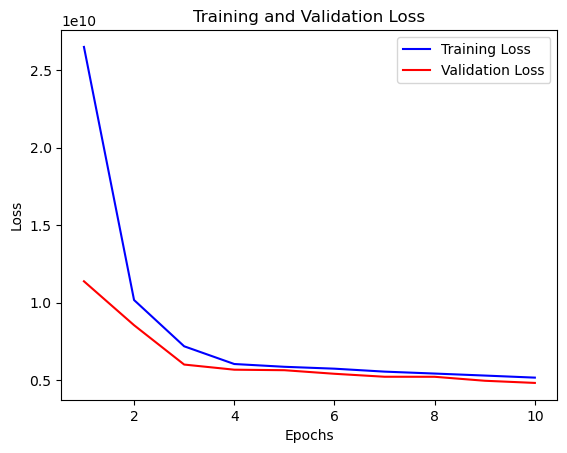

In [37]:
# Get the training and validation loss from the history object
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss) + 1)
# Plot the training and validation loss
plt.plot(epochs, training_loss, 'b', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')

# Label the plot
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

# Save model

In [38]:
model.save("model_ann.h5")

import pickle
pickle.dump(min_max_scaler,open('scaler.pkl','wb'))